In [50]:
# deployment of the app on the streamlit
# https://attendancepredictionmlmodel-4f5nyuwgqd9ot2mtmepyux.streamlit.app/

In [51]:
# git repo link 
# https://github.com/niharikasingh-projects/AttendancePredictionMLModel

In [52]:
# step 1 importing libraries and loading the csv file 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv("student_attendance_of_mca_semester_3.csv")
df.head()

,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Attendance_Percentage,Previous_Lecture_Attendance_Pct,Gap_Since_Previous_Lecture_Hours,Practical_or_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event,Faculty_Experience_Years
0,15-06-2026,Monday,1,08:30:00,09:15:00,Mobile Application Development,F_SSP,3,MCA,A,...,59.22,NaN,NaN,Theory,No,No,No,Cloudy,No,9
1,15-06-2026,Monday,2,09:15:00,10:15:00,Mobile Application Development,F_SSP,3,MCA,A,...,60.19,59.22,0.00,Theory,No,No,No,Cloudy,No,9
2,15-06-2026,Monday,3,10:15:00,11:15:00,Software Testing and Quality Assurance,F_DPY,3,MCA,A,...,74.76,60.19,0.00,Theory,No,No,No,Sunny,No,6
3,15-06-2026,Monday,4,11:15:00,12:15:00,Principles of Cloud Management and Security,F_KSD,3,MCA,A,...,58.25,74.76,0.00,Theory,No,No,No,Rainy,No,7
4,15-06-2026,Monday,5,13:30:00,15:30:00,Innovation and Entrepreneurship Development,F_JSP,3,MCA,A,...,27.18,58.25,1.25,Theory,No,No,No,Sunny,Yes,12


In [54]:
#  Step 2 :  Initial Data Exploration

# 1. Shape of the dataset
print("Shape (rows, columns):", df.shape)
print() 

# 2. Column names
print("Columns:\n", df.columns.tolist())
print() 

# 3. Data types and non-null counts
print("Info:")
df.info()
print() 

# 4. First 5 rows
print("First 5 rows:")
display(df.head())    
print()

# 5. Last 5 rows
print("Last 5 rows:")
display(df.tail())
print()

# 6. Statistical summary (numeric columns)
print("Summary statistics (numeric columns):")
display(df.describe())
print() 

# 7. Statistical summary (categorical/object columns)
print("Summary statistics (categorical columns):")
display(df.describe(include='object'))
print() 

# 8. Missing values per column
print("Missing values per column:")
print(df.isnull().sum())
print() 

# 9. Percentage of missing values per column
print("Missing values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))
print() 

# 10. Duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())
print() 

Shape (rows, columns): (514, 23)

Columns:
 ['Date', 'Day_of_Week', 'Lecture_Number', 'Start_Time', 'End_Time', 'Subject', 'Faculty_ID', 'Semester', 'Branch', 'Section', 'Classroom', 'Total_Enrolled_Students', 'Students_Present', 'Attendance_Percentage', 'Previous_Lecture_Attendance_Pct', 'Gap_Since_Previous_Lecture_Hours', 'Practical_or_Theory', 'Internal_Test_Week', 'Assignment_Due', 'Holiday_Before_After', 'Weather', 'Special_Event', 'Faculty_Experience_Years']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Date                              514 non-null    str    
 1   Day_of_Week                       514 non-null    str    
 2   Lecture_Number                    514 non-null    int64  
 3   Start_Time                        514 non-null    str    
 4   End_Time                          514 non-null 

,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Attendance_Percentage,Previous_Lecture_Attendance_Pct,Gap_Since_Previous_Lecture_Hours,Practical_or_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event,Faculty_Experience_Years
0,15-06-2026,Monday,1,08:30:00,09:15:00,Mobile Application Development,F_SSP,3,MCA,A,...,59.22,NaN,NaN,Theory,No,No,No,Cloudy,No,9
1,15-06-2026,Monday,2,09:15:00,10:15:00,Mobile Application Development,F_SSP,3,MCA,A,...,60.19,59.22,0.00,Theory,No,No,No,Cloudy,No,9
2,15-06-2026,Monday,3,10:15:00,11:15:00,Software Testing and Quality Assurance,F_DPY,3,MCA,A,...,74.76,60.19,0.00,Theory,No,No,No,Sunny,No,6
3,15-06-2026,Monday,4,11:15:00,12:15:00,Principles of Cloud Management and Security,F_KSD,3,MCA,A,...,58.25,74.76,0.00,Theory,No,No,No,Rainy,No,7
4,15-06-2026,Monday,5,13:30:00,15:30:00,Innovation and Entrepreneurship Development,F_JSP,3,MCA,A,...,27.18,58.25,1.25,Theory,No,No,No,Sunny,Yes,12



Last 5 rows:


,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Attendance_Percentage,Previous_Lecture_Attendance_Pct,Gap_Since_Previous_Lecture_Hours,Practical_or_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event,Faculty_Experience_Years
509,14-08-2026,Friday,1,08:30:00,09:15:00,Mobile Application Development,F_SSP,3,MCA,B,...,61.39,NaN,NaN,Theory,No,No,Before,Rainy,No,9
510,14-08-2026,Friday,2,09:15:00,10:15:00,Mobile Application Development,F_SSP,3,MCA,B,...,69.31,61.39,0.00,Theory,No,No,Before,Rainy,No,9
511,14-08-2026,Friday,3,10:15:00,11:15:00,Principles of Cloud Management and Security,F_KSD,3,MCA,B,...,78.22,69.31,0.00,Theory,No,No,Before,Sunny,No,7
512,14-08-2026,Friday,4,11:15:00,12:15:00,Data Science & Machine Learning,F_SP,3,MCA,B,...,59.41,78.22,0.00,Theory,No,No,Before,Cloudy,No,8
513,14-08-2026,Friday,5,13:30:00,15:30:00,DS & ML Practical,F_MLK,3,MCA,B,...,64.36,59.41,1.25,Practical,No,No,Before,Rainy,No,11



Summary statistics (numeric columns):


,Lecture_Number,Semester,Total_Enrolled_Students,Students_Present,Attendance_Percentage,Previous_Lecture_Attendance_Pct,Gap_Since_Previous_Lecture_Hours,Faculty_Experience_Years
count,514.000000,514.0,514.000000,514.000000,514.000000,408.000000,408.000000,514.000000
mean,2.937743,3.0,102.000000,73.472763,72.023074,72.434338,0.275735,8.848249
std,1.391990,0.0,1.000974,13.283248,12.950020,12.833613,0.518940,2.444775
min,1.000000,3.0,101.000000,21.000000,20.790000,20.790000,0.000000,4.000000
25%,2.000000,3.0,101.000000,65.000000,63.370000,64.360000,0.000000,7.000000
50%,3.000000,3.0,102.000000,74.000000,71.840000,72.280000,0.000000,9.000000
75%,4.000000,3.0,103.000000,82.000000,81.190000,81.190000,0.000000,9.000000
max,5.000000,3.0,103.000000,103.000000,100.000000,100.000000,1.250000,15.000000



Summary statistics (categorical columns):


,Date,Day_of_Week,Start_Time,End_Time,Subject,Faculty_ID,Branch,Section,Classroom,Practical_or_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event
count,514,514,514,514,514,514,514,514,514,514,514,514,514,514,514
unique,53,6,5,5,9,8,1,2,1,2,2,2,3,3,2
top,15-06-2026,Monday,08:30:00,09:15:00,Mobile Application Development,F_SSP,MCA,A,Computer Lab,Theory,No,No,No,Rainy,No
freq,10,90,106,106,212,212,514,257,514,396,406,466,446,229,493



Missing values per column:
Date                                  0
Day_of_Week                           0
Lecture_Number                        0
Start_Time                            0
End_Time                              0
Subject                               0
Faculty_ID                            0
Semester                              0
Branch                                0
Section                               0
Classroom                             0
Total_Enrolled_Students               0
Students_Present                      0
Attendance_Percentage                 0
Previous_Lecture_Attendance_Pct     106
Gap_Since_Previous_Lecture_Hours    106
Practical_or_Theory                   0
Internal_Test_Week                    0
Assignment_Due                        0
Holiday_Before_After                  0
Weather                               0
Special_Event                         0
Faculty_Experience_Years              0
dtype: int64

Missing values (%):
Date              

In [55]:
# 3.2 handling the missing values 

# Flag rows that are the first lecture of the day (before filling, so we capture the NaN pattern)
df['Is_First_Lecture_Of_Day'] = df['Previous_Lecture_Attendance_Pct'].isnull().astype(int)

# Gap since previous lecture -> 0 makes sense (no gap, it's the first lecture)
df['Gap_Since_Previous_Lecture_Hours'] = df['Gap_Since_Previous_Lecture_Hours'].fillna(0)

# Previous lecture attendance -> use a sentinel value (-1) rather than mean/median,
# so we don't fabricate a fake "previous attendance" for lectures that had none
df['Previous_Lecture_Attendance_Pct'] = df['Previous_Lecture_Attendance_Pct'].fillna(-1)


In [56]:
# Again checking for the missing values 
print("Missing values per column:")
print(df.isnull().sum())
print() 

Missing values per column:
Date                                0
Day_of_Week                         0
Lecture_Number                      0
Start_Time                          0
End_Time                            0
Subject                             0
Faculty_ID                          0
Semester                            0
Branch                              0
Section                             0
Classroom                           0
Total_Enrolled_Students             0
Students_Present                    0
Attendance_Percentage               0
Previous_Lecture_Attendance_Pct     0
Gap_Since_Previous_Lecture_Hours    0
Practical_or_Theory                 0
Internal_Test_Week                  0
Assignment_Due                      0
Holiday_Before_After                0
Weather                             0
Special_Event                       0
Faculty_Experience_Years            0
Is_First_Lecture_Of_Day             0
dtype: int64



In [57]:
# ---- 3.3 Convert Date and Time columns to proper types ----
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce').dt.time
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce').dt.time


In [58]:
# ---- 3.4 Check for logical/data-entry errors ----

# Students_Present should never exceed Total_Enrolled_Students
invalid_rows = df[df['Students_Present'] > df['Total_Enrolled_Students']]
print("Rows where Present > Enrolled:", len(invalid_rows))
display(invalid_rows)

# Attendance_Percentage should roughly match (Present/Enrolled)*100 -- verify consistency
df['Calculated_Attendance_Pct'] = (df['Students_Present'] / df['Total_Enrolled_Students'] * 100).round(2)
mismatch = df[abs(df['Attendance_Percentage'] - df['Calculated_Attendance_Pct']) > 0.5]
print("Rows where Attendance_Percentage doesn't match calculated value:", len(mismatch))
display(mismatch)

Rows where Present > Enrolled: 0


,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Previous_Lecture_Attendance_Pct,Gap_Since_Previous_Lecture_Hours,Practical_or_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event,Faculty_Experience_Years,Is_First_Lecture_Of_Day


Rows where Attendance_Percentage doesn't match calculated value: 0


,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Gap_Since_Previous_Lecture_Hours,Practical_or_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event,Faculty_Experience_Years,Is_First_Lecture_Of_Day,Calculated_Attendance_Pct


In [59]:
# ---- 3.5 Standardize categorical/text columns ----
categorical_cols = ['Day_of_Week', 'Subject', 'Branch', 'Section', 'Practical_or_Theory',
                     'Internal_Test_Week', 'Assignment_Due', 'Holiday_Before_After',
                     'Weather', 'Special_Event']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# ---- 3.6 Remove duplicate rows, if any ----
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")

# ---- 3.6 Final check ----
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned dataset shape:", df.shape)
df.head()

Removed 0 duplicate rows

Missing values after cleaning:
Date                                0
Day_of_Week                         0
Lecture_Number                      0
Start_Time                          0
End_Time                            0
Subject                             0
Faculty_ID                          0
Semester                            0
Branch                              0
Section                             0
Classroom                           0
Total_Enrolled_Students             0
Students_Present                    0
Attendance_Percentage               0
Previous_Lecture_Attendance_Pct     0
Gap_Since_Previous_Lecture_Hours    0
Practical_or_Theory                 0
Internal_Test_Week                  0
Assignment_Due                      0
Holiday_Before_After                0
Weather                             0
Special_Event                       0
Faculty_Experience_Years            0
Is_First_Lecture_Of_Day             0
Calculated_Attendance_Pct      

,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Gap_Since_Previous_Lecture_Hours,Practical_or_Theory,Internal_Test_Week,Assignment_Due,Holiday_Before_After,Weather,Special_Event,Faculty_Experience_Years,Is_First_Lecture_Of_Day,Calculated_Attendance_Pct
0,2026-06-15,Monday,1,08:30:00,09:15:00,Mobile Application Development,F_SSP,3,Mca,A,...,0.00,Theory,No,No,No,Cloudy,No,9,1,59.22
1,2026-06-15,Monday,2,09:15:00,10:15:00,Mobile Application Development,F_SSP,3,Mca,A,...,0.00,Theory,No,No,No,Cloudy,No,9,0,60.19
2,2026-06-15,Monday,3,10:15:00,11:15:00,Software Testing And Quality Assurance,F_DPY,3,Mca,A,...,0.00,Theory,No,No,No,Sunny,No,6,0,74.76
3,2026-06-15,Monday,4,11:15:00,12:15:00,Principles Of Cloud Management And Security,F_KSD,3,Mca,A,...,0.00,Theory,No,No,No,Rainy,No,7,0,58.25
4,2026-06-15,Monday,5,13:30:00,15:30:00,Innovation And Entrepreneurship Development,F_JSP,3,Mca,A,...,1.25,Theory,No,No,No,Sunny,Yes,12,0,27.18


In [60]:
# Step 4: Feature Engineering

# ---- 4.1 Day of semester / Week number ----
# Day of semester = how many days since the semester's first recorded lecture
semester_start_date = df['Date'].min()
df['Day_Of_Semester'] = (df['Date'] - semester_start_date).dt.days + 1

# Week number of semester (1-indexed)
df['Week_Number'] = ((df['Day_Of_Semester'] - 1) // 7) + 1

# ---- 4.2 Days since last holiday ----
# Holiday_Before_After tells us if a holiday happened right before/after this lecture's date
# We build a running "days since last holiday" counter across the sorted timeline
df = df.sort_values('Date').reset_index(drop=True)

days_since_holiday = []
last_holiday_date = None

for _, row in df.iterrows():
    if row['Holiday_Before_After'] == 'Yes':
        last_holiday_date = row['Date']
        days_since_holiday.append(0)
    else:
        if last_holiday_date is not None:
            days_since_holiday.append((row['Date'] - last_holiday_date).days)
        else:
            days_since_holiday.append(-1)   # no holiday seen yet in the data

df['Days_Since_Last_Holiday'] = days_since_holiday

# ---- 4.3 Consecutive lecture count per day ----
# For each Date, number lectures 1, 2, 3... in the order they occur that day
df['Consecutive_Lecture_Count'] = df.groupby('Date').cumcount() + 1

# ---- 4.4 Rolling average of previous 3 lectures' attendance ----
# Sort chronologically first (by date, then lecture number) so "previous" is meaningful
df = df.sort_values(['Date', 'Lecture_Number']).reset_index(drop=True)

df['Rolling_Avg_Prev_3_Lectures'] = (
    df['Attendance_Percentage']
    .shift(1)                     # exclude the current lecture itself
    .rolling(window=3, min_periods=1)
    .mean()
)

# Fill any remaining NaN (very first few lectures with no history) with -1 sentinel
df['Rolling_Avg_Prev_3_Lectures'] = df['Rolling_Avg_Prev_3_Lectures'].fillna(-1)

# ---- 4.5 Time-of-day clustering ----
def classify_time_of_day(start_time):
    hour = start_time.hour
    if hour < 12:
        return 'Morning'
    elif hour < 14:
        return 'Before Lunch'
    else:
        return 'Afternoon'

df['Time_Of_Day'] = df['Start_Time'].apply(classify_time_of_day)

# ---- 4.6 "Week before exam" binary flag ----
# Internal_Test_Week already flags exam week itself;
# here we flag the week immediately BEFORE an exam week (using Week_Number)
exam_weeks = df.loc[df['Internal_Test_Week'] == 'Yes', 'Week_Number'].unique()
week_before_exam_numbers = set(w - 1 for w in exam_weeks)

df['Week_Before_Exam'] = df['Week_Number'].isin(week_before_exam_numbers).map({True: 'Yes', False: 'No'})

# ---- Final check ----
print("New engineered columns added:")
print(['Day_Of_Semester', 'Week_Number', 'Days_Since_Last_Holiday',
       'Consecutive_Lecture_Count', 'Rolling_Avg_Prev_3_Lectures',
       'Time_Of_Day', 'Week_Before_Exam'])

df[['Date', 'Lecture_Number', 'Day_Of_Semester', 'Week_Number',
    'Days_Since_Last_Holiday', 'Consecutive_Lecture_Count',
    'Rolling_Avg_Prev_3_Lectures', 'Time_Of_Day', 'Week_Before_Exam']].head(10)

df.head() 

New engineered columns added:
['Day_Of_Semester', 'Week_Number', 'Days_Since_Last_Holiday', 'Consecutive_Lecture_Count', 'Rolling_Avg_Prev_3_Lectures', 'Time_Of_Day', 'Week_Before_Exam']


,Date,Day_of_Week,Lecture_Number,Start_Time,End_Time,Subject,Faculty_ID,Semester,Branch,Section,...,Faculty_Experience_Years,Is_First_Lecture_Of_Day,Calculated_Attendance_Pct,Day_Of_Semester,Week_Number,Days_Since_Last_Holiday,Consecutive_Lecture_Count,Rolling_Avg_Prev_3_Lectures,Time_Of_Day,Week_Before_Exam
0,2026-06-15,Monday,1,08:30:00,09:15:00,Mobile Application Development,F_SSP,3,Mca,A,...,9,1,59.22,1,1,-1,1,-1.000000,Morning,Yes
1,2026-06-15,Monday,1,08:30:00,09:15:00,Mobile Application Development,F_SSP,3,Mca,B,...,9,1,63.37,1,1,-1,6,59.220000,Morning,Yes
2,2026-06-15,Monday,2,09:15:00,10:15:00,Mobile Application Development,F_SSP,3,Mca,A,...,9,0,60.19,1,1,-1,2,61.295000,Morning,Yes
3,2026-06-15,Monday,2,09:15:00,10:15:00,Mobile Application Development,F_SSP,3,Mca,B,...,9,0,52.48,1,1,-1,7,60.926667,Morning,Yes
4,2026-06-15,Monday,3,10:15:00,11:15:00,Software Testing And Quality Assurance,F_DPY,3,Mca,A,...,6,0,74.76,1,1,-1,3,58.680000,Morning,Yes


In [61]:
# STEP 5: TIME CONVERSION & CATEGORICAL ENCODING

# ---- 5.1 Convert Start_Time to Integer Features ----
start_dt = pd.to_datetime(df['Start_Time'].astype(str), format='%H:%M:%S', errors='coerce')

# Total minutes from midnight (e.g., 08:30 -> 510)
df['Start_Time_Minutes'] = (start_dt.dt.hour * 60 + start_dt.dt.minute).astype(int)

# Start Hour (e.g., 8, 9, 10, 11, 13)
df['Start_Hour'] = start_dt.dt.hour.astype(int)

# ---- 5.2 Drop Redundant, Constant, and Raw Datetime Columns ----
# 'Branch': Single unique value ('Mca')
# 'Classroom': Redundant with 'Section'
# 'Semester': Single unique value (3)
# Raw Date/Time strings: Replaced by engineered numeric features (Day_Of_Semester, Start_Time_Minutes, etc.)
cols_to_drop = ['Branch', 'Classroom', 'Semester', 'Date', 'Start_Time', 'End_Time', 'Start_Time_Dt', 'End_Time_Dt']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# ---- 5.3 Separate Categorical Columns ----

# 1. Binary Columns (Yes / No flags) -> Convert to 1 / 0
binary_cols = [
    'Internal_Test_Week',
    'Assignment_Due',
    'Special_Event',
    'Week_Before_Exam'
]

# 2. Multi-Category Columns -> One-Hot Encoding
one_hot_cols = [
    'Day_of_Week',
    'Subject',
    'Faculty_ID',
    'Section',
    'Practical_or_Theory',
    'Holiday_Before_After',
    'Weather',
    'Time_Of_Day'
]

print("Binary Encoding Columns:", binary_cols)
print("One-Hot Encoding Columns:", one_hot_cols)
print()

# ---- 5.4 Apply Binary Encoding (Mapping Yes -> 1, No -> 0) ----
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# ---- 5.5 Apply One-Hot Encoding using pd.get_dummies() ----
df_encoded = pd.get_dummies(df, columns=one_hot_cols, drop_first=True, dtype=int)

# ---- 5.6 Check Transformed Encoded Dataset ----
print("Encoded Dataset Shape:", df_encoded.shape)
print("\nFirst 5 rows of Encoded Dataset:")
display(df_encoded.head())

print("\nAll Encoded Columns:")
print(df_encoded.columns.tolist())

Binary Encoding Columns: ['Internal_Test_Week', 'Assignment_Due', 'Special_Event', 'Week_Before_Exam']
One-Hot Encoding Columns: ['Day_of_Week', 'Subject', 'Faculty_ID', 'Section', 'Practical_or_Theory', 'Holiday_Before_After', 'Weather', 'Time_Of_Day']

Encoded Dataset Shape: (514, 47)

First 5 rows of Encoded Dataset:


,Lecture_Number,Total_Enrolled_Students,Students_Present,Attendance_Percentage,Previous_Lecture_Attendance_Pct,Gap_Since_Previous_Lecture_Hours,Internal_Test_Week,Assignment_Due,Special_Event,Faculty_Experience_Years,...,Faculty_ID_F_SP,Faculty_ID_F_SSP,Faculty_ID_F_Visiting,Section_B,Practical_or_Theory_Theory,Holiday_Before_After_Before,Holiday_Before_After_No,Weather_Rainy,Weather_Sunny,Time_Of_Day_Morning
0,1,103,61,59.22,-1.00,0.0,0,0,0,9,...,0,1,0,0,1,0,1,0,0,1
1,1,101,64,63.37,-1.00,0.0,0,0,0,9,...,0,1,0,1,1,0,1,0,0,1
2,2,103,62,60.19,59.22,0.0,0,0,0,9,...,0,1,0,0,1,0,1,0,0,1
3,2,101,53,52.48,63.37,0.0,0,0,0,9,...,0,1,0,1,1,0,1,1,0,1
4,3,103,77,74.76,60.19,0.0,0,0,0,6,...,0,0,0,0,1,0,1,0,1,1



All Encoded Columns:
['Lecture_Number', 'Total_Enrolled_Students', 'Students_Present', 'Attendance_Percentage', 'Previous_Lecture_Attendance_Pct', 'Gap_Since_Previous_Lecture_Hours', 'Internal_Test_Week', 'Assignment_Due', 'Special_Event', 'Faculty_Experience_Years', 'Is_First_Lecture_Of_Day', 'Calculated_Attendance_Pct', 'Day_Of_Semester', 'Week_Number', 'Days_Since_Last_Holiday', 'Consecutive_Lecture_Count', 'Rolling_Avg_Prev_3_Lectures', 'Week_Before_Exam', 'Start_Time_Minutes', 'Start_Hour', 'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday', 'Subject_Ds & Ml Practical', 'Subject_Industry Readiness Program', 'Subject_Innovation And Entrepreneurship Development', 'Subject_Mini Project', 'Subject_Mobile Application Development', 'Subject_Principles Of Cloud Management And Security', 'Subject_Software Testing And Quality Assurance', 'Subject_Stqa Practical', 'Faculty_ID_F_JSP', 'Faculty_ID_F_KSD', 'Faculty_ID_F_MLK', '

In [62]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 47 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Lecture_Number                                       514 non-null    int64  
 1   Total_Enrolled_Students                              514 non-null    int64  
 2   Students_Present                                     514 non-null    int64  
 3   Attendance_Percentage                                514 non-null    float64
 4   Previous_Lecture_Attendance_Pct                      514 non-null    float64
 5   Gap_Since_Previous_Lecture_Hours                     514 non-null    float64
 6   Internal_Test_Week                                   514 non-null    int64  
 7   Assignment_Due                                       514 non-null    int64  
 8   Special_Event                                        514 non-null    int64  
 9  

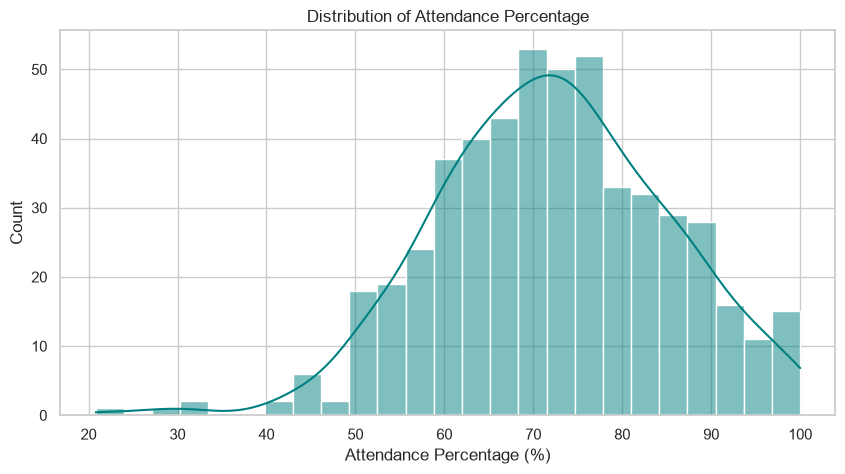

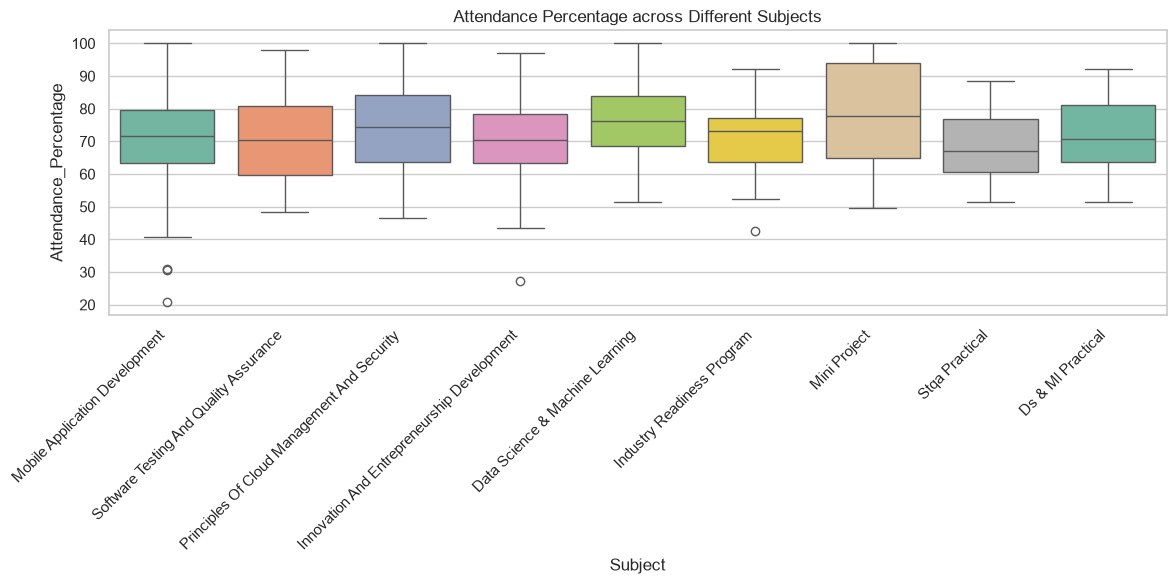

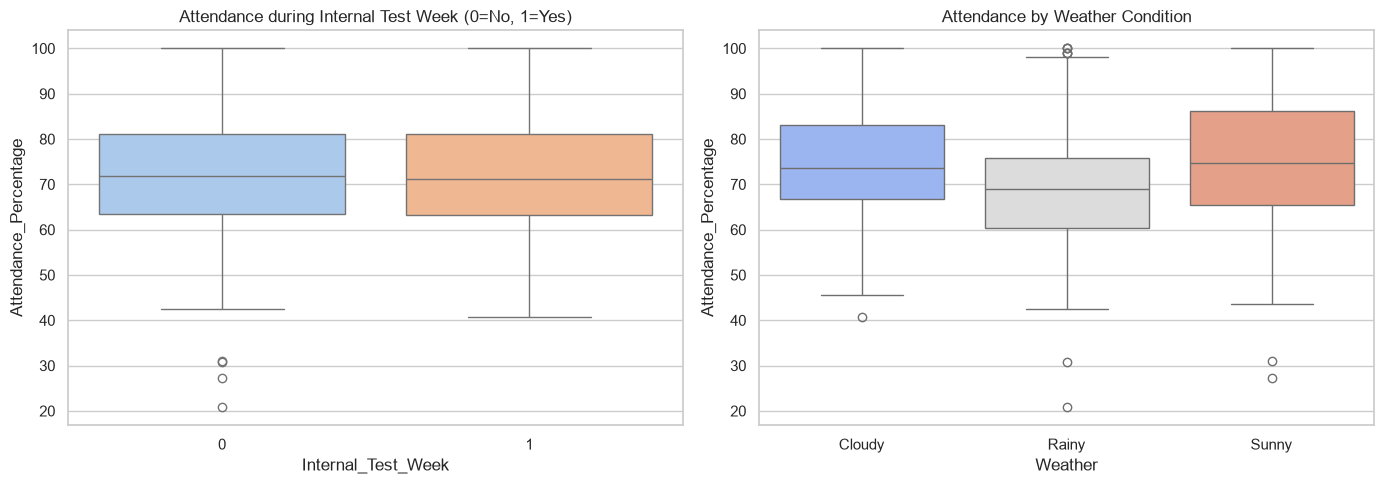

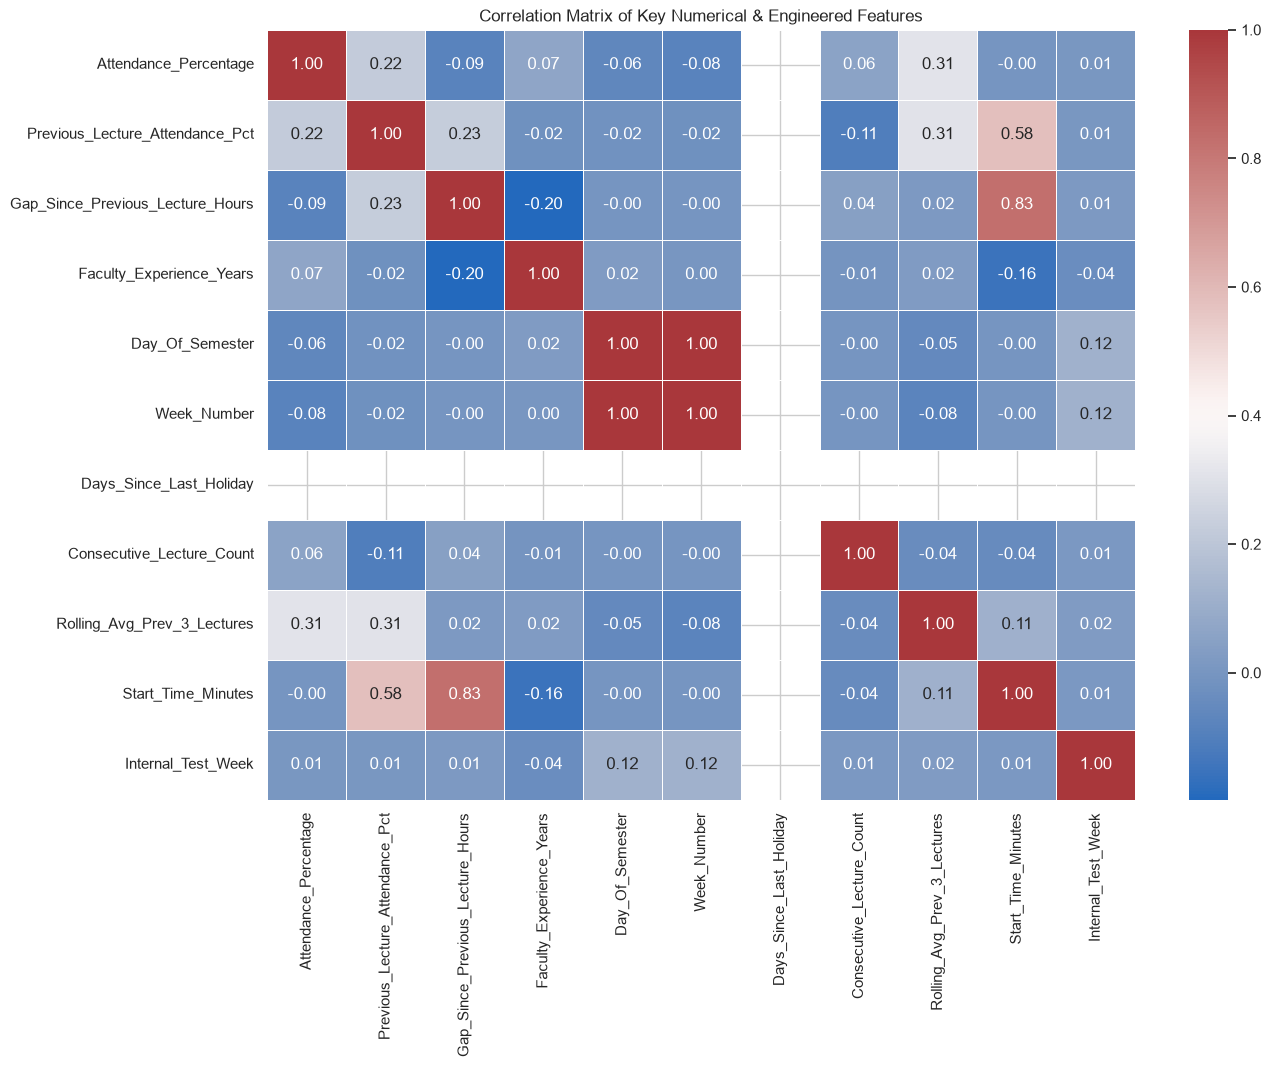

In [63]:
# STEP 6: EXPLORATORY DATA ANALYSIS & VISUALIZATION


# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---- 6.1 Distribution of Target Variable (Attendance Percentage) ----
plt.figure(figsize=(10, 5))
sns.histplot(df['Attendance_Percentage'], kde=True, bins=25, color='teal')
plt.title('Distribution of Attendance Percentage')
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Count')
plt.show()

# ---- 6.2 Attendance Percentage by Subject ----
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Subject', y='Attendance_Percentage', palette='Set2')
plt.title('Attendance Percentage across Different Subjects')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---- 6.3 Impact of Internal Test Week & Weather ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Internal_Test_Week', y='Attendance_Percentage', ax=axes[0], palette='pastel')
axes[0].set_title('Attendance during Internal Test Week (0=No, 1=Yes)')

sns.boxplot(data=df, x='Weather', y='Attendance_Percentage', ax=axes[1], palette='coolwarm')
axes[1].set_title('Attendance by Weather Condition')

plt.tight_layout()
plt.show()

# ---- 6.4 Correlation Matrix Heatmap ----
plt.figure(figsize=(14, 10))
# Calculate correlation on key numerical features
corr_cols = [
    'Attendance_Percentage', 'Previous_Lecture_Attendance_Pct',
    'Gap_Since_Previous_Lecture_Hours', 'Faculty_Experience_Years',
    'Day_Of_Semester', 'Week_Number', 'Days_Since_Last_Holiday',
    'Consecutive_Lecture_Count', 'Rolling_Avg_Prev_3_Lectures',
    'Start_Time_Minutes', 'Internal_Test_Week'
]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='vlag', linewidths=0.5)
plt.title('Correlation Matrix of Key Numerical & Engineered Features')
plt.show()

Features dataset shape after dropping redundant/leakage columns: (514, 41)
Total predictor features available: 41


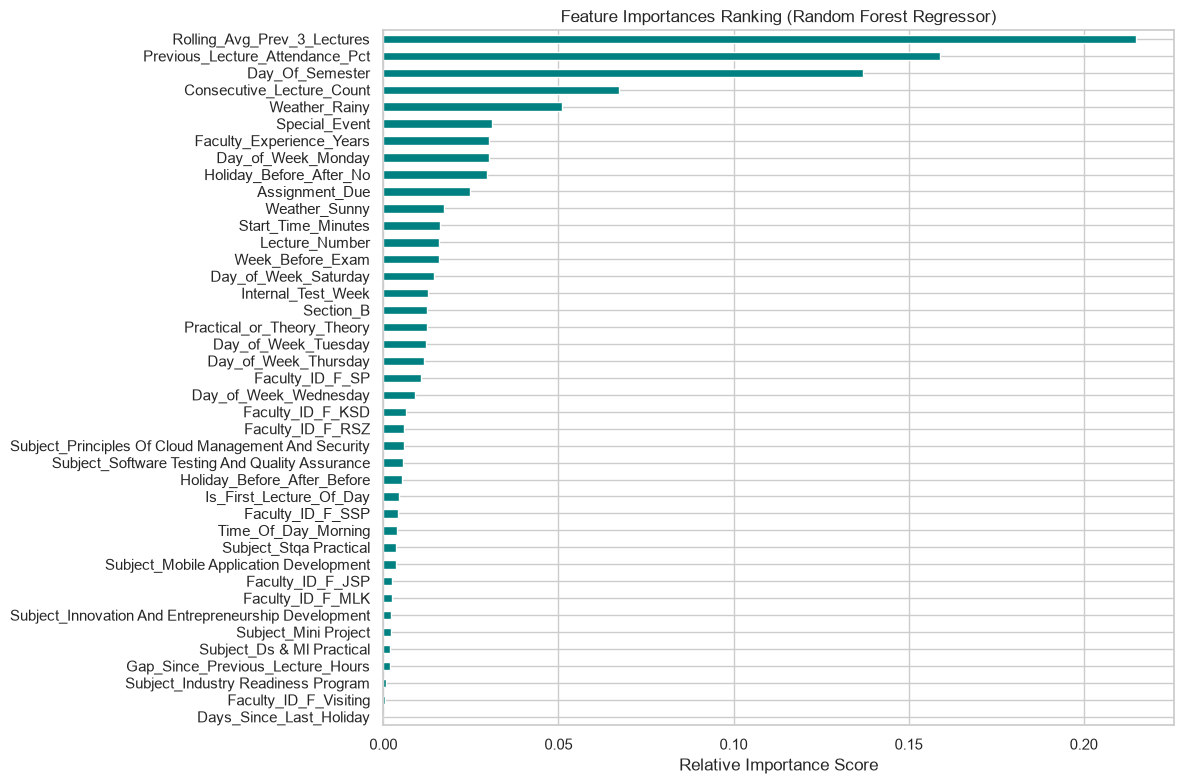


--- TOP 10 MOST IMPORTANT FEATURES ---


Rolling_Avg_Prev_3_Lectures        0.215023
Previous_Lecture_Attendance_Pct    0.158879
Day_Of_Semester                    0.137002
Consecutive_Lecture_Count          0.067387
Weather_Rainy                      0.051143
Special_Event                      0.031044
Faculty_Experience_Years           0.030234
Day_of_Week_Monday                 0.030115
Holiday_Before_After_No            0.029659
Assignment_Due                     0.024814
dtype: float64


Final Selected Features Count: 27 out of 41
Selected Features list:
['Rolling_Avg_Prev_3_Lectures', 'Previous_Lecture_Attendance_Pct', 'Day_Of_Semester', 'Consecutive_Lecture_Count', 'Weather_Rainy', 'Special_Event', 'Faculty_Experience_Years', 'Day_of_Week_Monday', 'Holiday_Before_After_No', 'Assignment_Due', 'Weather_Sunny', 'Start_Time_Minutes', 'Lecture_Number', 'Week_Before_Exam', 'Day_of_Week_Saturday', 'Internal_Test_Week', 'Section_B', 'Practical_or_Theory_Theory', 'Day_of_Week_Tuesday', 'Day_of_Week_Thursday', 'Faculty_ID_F_SP', 'Day_of_Week_Wednesday', 'Faculty_ID_F_KSD', 'Faculty_ID_F_RSZ', 'Subject_Principles Of Cloud Management And Security', 'Subject_Software Testing And Quality Assurance', 'Holiday_Before_After_Before']


In [64]:
# STEP 7: FEATURE SELECTION

# ---- 7.1 Drop Target Leakage & Redundant Multicollinear Columns ----
leakage_and_redundant_cols = [
    'Students_Present',            # Target leakage
    'Calculated_Attendance_Pct',    # Target leakage
    'Total_Enrolled_Students',     # Target leakage (constant 101/103)
    'Week_Number',                 # 100% correlated with Day_Of_Semester
    'Start_Hour'                   # Redundant with Start_Time_Minutes
]

# Create X (Predictor Features) and y (Target)
X = df_encoded.drop(columns=['Attendance_Percentage'] + [c for c in leakage_and_redundant_cols if c in df_encoded.columns])
y = df_encoded['Attendance_Percentage']

print(f"Features dataset shape after dropping redundant/leakage columns: {X.shape}")
print(f"Total predictor features available: {X.shape[1]}")

# ---- 7.2 Feature Importance Ranking using Random Forest ----
from sklearn.ensemble import RandomForestRegressor


# Fit a Random Forest Regressor to evaluate feature importances
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extract and rank feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importances Ranking (Random Forest Regressor)')
plt.xlabel('Relative Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n--- TOP 10 MOST IMPORTANT FEATURES ---")
display(importances.head(10))

# ---- 7.3 Select Top Features (Thresholding) ----
# Filter out features with near-zero importance (e.g. importance < 0.01)
important_features = importances[importances >= 0.005].index.tolist()

X_selected = X[important_features]

print(f"\nFinal Selected Features Count: {len(important_features)} out of {X.shape[1]}")
print("Selected Features list:")
print(important_features)

In [65]:
# STEP 8: TRAIN-TEST SPLIT & FEATURE STANDARDIZATION


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---- 8.1 Create Dedicated Selected Features DataFrame ----
df_final_features = X_selected.copy()

print(f"Dedicated Selected Features DataFrame Shape: {df_final_features.shape}")
print("Selected Features list:", df_final_features.columns.tolist())
print()

# ---- 8.2 Train-Test Split (80% Training, 20% Testing) ----
X_train, X_test, y_train, y_test = train_test_split(
    df_final_features, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print()

# ---- 8.3 Identify Continuous Numerical Columns to Scale ----
# We scale continuous numerical columns while keeping binary/one-hot 0/1 columns untouched
all_continuous_cols = [
    'Gap_Since_Previous_Lecture_Hours',
    'Previous_Lecture_Attendance_Pct',
    'Faculty_Experience_Years',
    'Day_Of_Semester',
    'Days_Since_Last_Holiday',
    'Consecutive_Lecture_Count',
    'Rolling_Avg_Prev_3_Lectures',
    'Start_Time_Minutes'
]

# Keep only continuous columns present in our selected features
num_cols_to_scale = [col for col in all_continuous_cols if col in df_final_features.columns]
print("Continuous Numerical Columns being scaled:", num_cols_to_scale)

# ---- 8.4 Apply StandardScaler ----
scaler = StandardScaler()

# Fit scaler ONLY on X_train (prevents data leakage), then transform both X_train & X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

# ---- 8.5 Verify Scaled Dataset ----
print("\n--- STANDARDIZATION COMPLETE ---")
print("First 5 rows of X_train_scaled:")
display(X_train_scaled.head())

Dedicated Selected Features DataFrame Shape: (514, 27)
Selected Features list: ['Rolling_Avg_Prev_3_Lectures', 'Previous_Lecture_Attendance_Pct', 'Day_Of_Semester', 'Consecutive_Lecture_Count', 'Weather_Rainy', 'Special_Event', 'Faculty_Experience_Years', 'Day_of_Week_Monday', 'Holiday_Before_After_No', 'Assignment_Due', 'Weather_Sunny', 'Start_Time_Minutes', 'Lecture_Number', 'Week_Before_Exam', 'Day_of_Week_Saturday', 'Internal_Test_Week', 'Section_B', 'Practical_or_Theory_Theory', 'Day_of_Week_Tuesday', 'Day_of_Week_Thursday', 'Faculty_ID_F_SP', 'Day_of_Week_Wednesday', 'Faculty_ID_F_KSD', 'Faculty_ID_F_RSZ', 'Subject_Principles Of Cloud Management And Security', 'Subject_Software Testing And Quality Assurance', 'Holiday_Before_After_Before']

X_train shape: (411, 27)
X_test shape:  (103, 27)
y_train shape: (411,)
y_test shape:  (103,)

Continuous Numerical Columns being scaled: ['Previous_Lecture_Attendance_Pct', 'Faculty_Experience_Years', 'Day_Of_Semester', 'Consecutive_Lecture_C

,Rolling_Avg_Prev_3_Lectures,Previous_Lecture_Attendance_Pct,Day_Of_Semester,Consecutive_Lecture_Count,Weather_Rainy,Special_Event,Faculty_Experience_Years,Day_of_Week_Monday,Holiday_Before_After_No,Assignment_Due,...,Practical_or_Theory_Theory,Day_of_Week_Tuesday,Day_of_Week_Thursday,Faculty_ID_F_SP,Day_of_Week_Wednesday,Faculty_ID_F_KSD,Faculty_ID_F_RSZ,Subject_Principles Of Cloud Management And Security,Subject_Software Testing And Quality Assurance,Holiday_Before_After_Before
320,-0.710212,-1.923943,0.430594,-0.485905,0,0,0.056790,0,1,0,...,1,0,1,0,0,0,0,0,0,0
329,0.104158,0.610853,0.430594,1.649998,1,1,-1.171673,0,1,0,...,0,0,1,0,0,0,0,0,0,0
173,1.746976,0.954969,-0.642319,1.294014,0,0,0.875766,0,1,0,...,0,0,0,0,0,0,0,0,0,0
272,-0.305991,-1.923943,0.091779,-0.129921,1,0,0.056790,0,0,0,...,1,0,0,0,0,0,0,0,0,1
493,-0.110735,0.360499,1.559976,-0.129921,1,0,2.513716,0,1,1,...,0,0,0,0,1,0,1,0,0,0


         REGRESSION MODEL PERFORMANCE MATRIX             


,Algorithm,MAE (%),RMSE (%),MAPE (%),R² Score
0,Linear Regression,8.247,11.171,12.63,0.1726
1,Random Forest Regressor,8.743,12.013,13.35,0.0432
2,XGBoost Regressor,9.073,12.244,13.81,0.0060
3,Gradient Boosting Regressor,9.263,13.628,14.14,-0.2314
4,Decision Tree Regressor,11.591,15.799,17.17,-0.6549


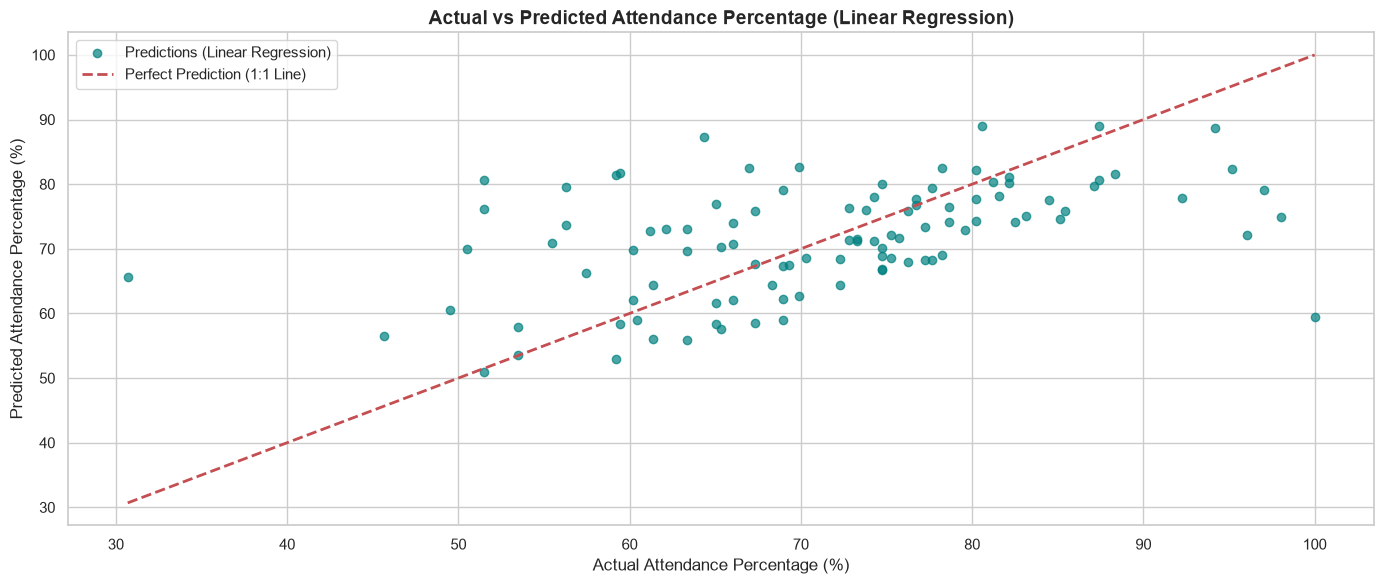

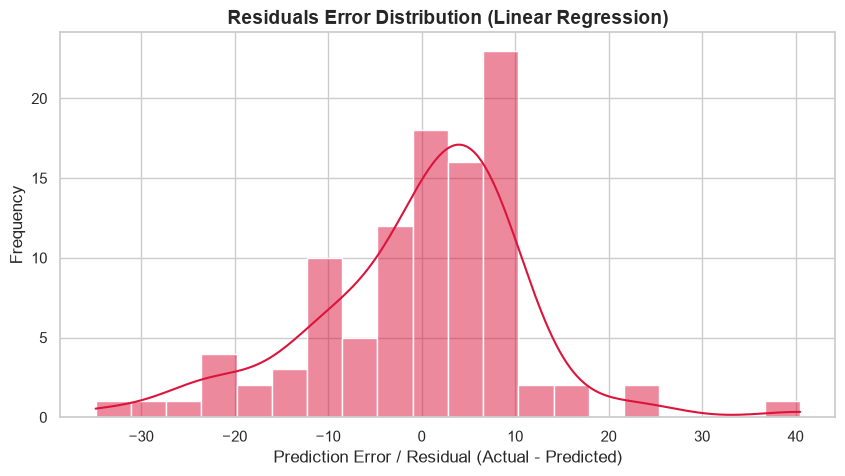

In [66]:
# STEP 9: REGRESSION ALGORITHMIC MODELING & EVALUATION

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- 9.1 Initialize Regression Models ----
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# ---- 9.2 Train, Predict, and Evaluate Metrics ----
results = []
predictions = {}

for name, model in models.items():
    # 1. Train Model
    model.fit(X_train_scaled, y_train)
    
    # 2. Predict on Test Set
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    # 3. Calculate Evaluation Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    
    # 4. Store Results
    results.append({
        'Algorithm': name,
        'MAE (%)': round(mae, 3),
        'RMSE (%)': round(rmse, 3),
        'MAPE (%)': round(mape, 2),
        'R² Score': round(r2, 4)
    })

# ---- 9.3 Display Regression Model Comparison Table ----
reg_summary_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False).reset_index(drop=True)

print("=========================================================")
print("         REGRESSION MODEL PERFORMANCE MATRIX             ")
print("=========================================================")
display(reg_summary_df)

# ---- 9.4 Visualization: Actual vs Predicted Attendance ----
plt.figure(figsize=(14, 6))

best_model_name = reg_summary_df.loc[0, 'Algorithm']
best_preds = predictions[best_model_name]

plt.scatter(y_test, best_preds, alpha=0.7, color='teal', label=f'Predictions ({best_model_name})')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction (1:1 Line)')

plt.title(f'Actual vs Predicted Attendance Percentage ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Attendance Percentage (%)', fontsize=12)
plt.ylabel('Predicted Attendance Percentage (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# ---- 9.5 Residuals Distribution (Error Analysis) ----
residuals = y_test - best_preds
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='crimson', bins=20)
plt.title(f'Residuals Error Distribution ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Error / Residual (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [67]:
# Add 'Model Accuracy (%)' column to the regression summary DataFrame
reg_summary_df['Model Accuracy (%)'] = (100 - reg_summary_df['MAPE (%)']).round(2)

# Display updated matrix sorted by Accuracy
reg_summary_df_sorted = reg_summary_df.sort_values(by='Model Accuracy (%)', ascending=False).reset_index(drop=True)

print("=========================================================")
print("       REGRESSION MODEL PERFORMANCE & ACCURACY           ")
print("=========================================================")
display(reg_summary_df_sorted[['Algorithm', 'Model Accuracy (%)', 'MAE (%)', 'RMSE (%)', 'R² Score']])

       REGRESSION MODEL PERFORMANCE & ACCURACY           


,Algorithm,Model Accuracy (%),MAE (%),RMSE (%),R² Score
0,Linear Regression,87.37,8.247,11.171,0.1726
1,Random Forest Regressor,86.65,8.743,12.013,0.0432
2,XGBoost Regressor,86.19,9.073,12.244,0.0060
3,Gradient Boosting Regressor,85.86,9.263,13.628,-0.2314
4,Decision Tree Regressor,82.83,11.591,15.799,-0.6549


In [68]:
# STEP 10: CLASSIFICATION ALGORITHMIC MODELING & EVALUATION

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# ---- 10.1 Prepare Classification Target (Attendance Band) ----
# Low (<50%), Medium (50-75%), High (>75%)
def classify_attendance_band(pct):
    if pct < 50.0:
        return 'Low'
    elif pct <= 75.0:
        return 'Medium'
    else:
        return 'High'

# Create classification target column
y_cls_raw = df['Attendance_Percentage'].apply(classify_attendance_band)

# Encode string labels to numerical classes (e.g. 0, 1, 2)
le = LabelEncoder()
y_cls_encoded = le.fit_transform(y_cls_raw)

# ---- 10.2 Train-Test Split (Stratified on Classification Classes) ----
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df_final_features, 
    y_cls_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_cls_encoded
)

# ---- 10.3 Standardize Numerical Features for Classification ----
X_train_c_scaled = X_train_c.copy()
X_test_c_scaled = X_test_c.copy()

X_train_c_scaled[num_cols_to_scale] = scaler.fit_transform(X_train_c[num_cols_to_scale])
X_test_c_scaled[num_cols_to_scale] = scaler.transform(X_test_c[num_cols_to_scale])

# ---- 10.4 Initialize Classification Models ----
cls_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine (SVM)': SVC(random_state=42),
    'k-Nearest Neighbors (k-NN)': KNeighborsClassifier(n_neighbors=5),
    'Naïve Bayes': GaussianNB(),
    'XGBoost Classifier': XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42)
}

# ---- 10.5 Train & Evaluate Models ----
cls_results = []
cls_predictions = {}

for name, model in cls_models.items():
    # 1. Train Model
    model.fit(X_train_c_scaled, y_train_c)
    
    # 2. Predict on Test Set
    y_pred = model.predict(X_test_c_scaled)
    cls_predictions[name] = y_pred
    
    # 3. Calculate Classification Metrics
    acc = accuracy_score(y_test_c, y_pred) * 100
    prec = precision_score(y_test_c, y_pred, average='weighted', zero_division=0) * 100
    rec = recall_score(y_test_c, y_pred, average='weighted', zero_division=0) * 100
    f1 = f1_score(y_test_c, y_pred, average='weighted', zero_division=0) * 100
    
    # 4. Store Results
    cls_results.append({
        'Algorithm': name,
        'Accuracy (%)': round(acc, 2),
        'Precision (%)': round(prec, 2),
        'Recall (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2)
    })

# ---- 10.6 Display Classification Summary Matrix ----
cls_summary_df = pd.DataFrame(cls_results).sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)

print("=========================================================")
print("        CLASSIFICATION MODEL PERFORMANCE MATRIX          ")
print("=========================================================")
display(cls_summary_df)

# ---- 10.7 Plot Confusion Matrix for Best Classifier ----
best_cls_name = cls_summary_df.loc[0, 'Algorithm']
best_cls_preds = cls_predictions[best_cls_name]

cm = confusion_matrix(y_test_c, best_cls_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)



        CLASSIFICATION MODEL PERFORMANCE MATRIX          


,Algorithm,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Logistic Regression,69.90,67.71,69.90,68.72
1,Random Forest Classifier,68.93,66.72,68.93,67.55
2,Support Vector Machine (SVM),68.93,66.78,68.93,67.38
3,XGBoost Classifier,68.93,69.27,68.93,68.45
4,Decision Tree Classifier,62.14,65.22,62.14,63.31
5,k-Nearest Neighbors (k-NN),61.17,58.88,61.17,59.78
6,Naïve Bayes,23.30,63.38,23.30,27.19


In [69]:
# =========================================================
# STEP 11: SAVE ALL MODEL ARTIFACTS USING JOBLIB (.pkl)
# =========================================================
import joblib
import os
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

# Create 'models' directory to store the .pkl files
os.makedirs('models', exist_ok=True)

# 1. Fit & Train the 3 Selected Models

# Model 1: Linear Regression (Regression)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Model 2: Random Forest Regressor (Regression)
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(X_train_scaled, y_train)

# Model 3: Logistic Regression (Classification)
log_reg_cls_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_cls_model.fit(X_train_c_scaled, y_train_c)

# 2. Save all artifacts as .pkl files using joblib.dump()
joblib.dump(lr_model, 'models/linear_regression_model.pkl')
joblib.dump(rf_reg_model, 'models/random_forest_regressor_model.pkl')
joblib.dump(log_reg_cls_model, 'models/logistic_regression_model.pkl')

joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le, 'models/label_encoder.pkl')
joblib.dump(df_final_features.columns.tolist(), 'models/selected_features.pkl')

print("=========================================================")
print("     ALL .pkl MODEL ARTIFACTS SAVED SUCCESSFULLY         ")
print("=========================================================")
print("1. models/linear_regression_model.pkl      (Linear Regression Regressor)")
print("2. models/random_forest_regressor_model.pkl (Random Forest Regressor)")
print("3. models/logistic_regression_model.pkl    (Logistic Regression Classifier)")
print("4. models/scaler.pkl                       (Fitted StandardScaler)")
print("5. models/label_encoder.pkl                (Fitted LabelEncoder)")
print("6. models/selected_features.pkl            (Selected Feature Column Names)")
print("=========================================================")

     ALL .pkl MODEL ARTIFACTS SAVED SUCCESSFULLY         
1. models/linear_regression_model.pkl      (Linear Regression Regressor)
2. models/random_forest_regressor_model.pkl (Random Forest Regressor)
3. models/logistic_regression_model.pkl    (Logistic Regression Classifier)
4. models/scaler.pkl                       (Fitted StandardScaler)
5. models/label_encoder.pkl                (Fitted LabelEncoder)
6. models/selected_features.pkl            (Selected Feature Column Names)
